In [ ]:
from astropy.io import ascii, fits
from astropy.table import Table
from run_prospector_new import *
from prospect.io import read_results as pread
import pandas as pd
import corner
import matplot.pyplot as plt
import numpy as np

In [ ]:
TAB = Table(ascii.read('sedrun.csv'))
ROW = TAB[0]
# FILE = 'out/.h5'
model = build_model(ROW)
sps = pread.get_sps(results)
model_params = model.theta_labels()
# from run_prosp_nonparaSFH import build_model, build_sps
results, observations_dict, _ = pread.results_from(FILE)

NameError: name 'TAB' is not defined

In [2]:
pread.subcorner(results, showpars=['dust2','duste_gamma','duste_umin','logmass','logzsol','gas_logz','gas_logu'])

NameError: name 'pread' is not defined

In [4]:
from tqdm.auto import tqdm
seds_spec = []
seds_mag = []
surviving_mass_frac = []

weights = results.get('weights',None) #likelihood values
idx = np.argsort(weights)[-5000:] #select 5000 most likely
for i in tqdm(idx):
    thetas = results['chain'][i]
    spec, mags, mass_frac = model.predict(thetas,sps=sps,obs=observations_dict)
    seds_spec.append(spec)
    seds_mag.append(mags)
    surviving_mass_frac.append(mass_frac)

corrected_stellar_mass_posterior = 10**results['chain'][idx,model_params.index('logmass')] * np.array(surviving_mass_frac) 

NameError: name 'results' is not defined

In [5]:
import matplotlib.pyplot as plt
n = plt.hist(np.log10(corrected_stellar_mass_posterior), range=(9, 12), bins=30)
plt.vlines(np.median(np.log10(corrected_stellar_mass_posterior)), ymin=0, ymax=np.max(n[0])+100, color='darkblue', label='Median')
plt.ylabel('M* Posterior')
plt.xlabel('$\log(M_* / M_{\odot})$')
plt.legend()

NameError: name 'np' is not defined

In [6]:
from prospect.models import transforms
def get_sfr(res, mod):
    agebins = mod.params['agebins']
    thetas = mod.theta_labels()                                                                                                                                           
    agebins_yrs = 10**agebins.T
    dt = agebins_yrs[1, :] - agebins_yrs[0, :]
    zfrac_idx = [i for i, s in enumerate(thetas) if 'z_fraction' in s]
    zfrac_chain = res['chain'][:,zfrac_idx[0]:zfrac_idx[-1]+1]
    
    total_mass_chain = res['chain'][:,thetas.index('logmass')]
    sfr_chain = []
    weights = results.get('weights',None) #likelihood values
    idx = np.argsort(weights)[-5000:]
    for i in idx:
        #this is the important part of this function -- it takes the proxy model parameters we sampled
        # and transforms them into the masses formed in each timebin
        # from there, we just divide these masses by the time in each bin to get the SFR in each bin
        masses_chain = transforms.zfrac_to_masses(10**total_mass_chain[i], zfrac_chain[i], agebins)
        sfr = masses_chain / dt                                                                                                                                  
        sfr_chain.append(sfr[0])                                                                                                                                                
    return sfr_chain

In [7]:
#now plot model SFR histogram

n, _, _ = plt.hist(model_sfr, range=(0,10), label='SFR posterior')
plt.title('SFR over the last 30 Myr')
plt.xlabel('SFR')
plt.legend()

NameError: name 'model_sfr' is not defined

In [ ]:
data = {'log(M$_*$/M$_{\odot}$)\n': np.log10(corrected_stellar_mass_posterior),
       'log(Z$_*$/Z$_{\odot}$)\n': results['chain'][idx,model_params.index('logzsol')],
       'log(SFR)\n': np.log10(model_sfr),
       'A$_V$\n': results['chain'][idx,model_params.index('dust2')]}
        
df = pd.DataFrame(data)

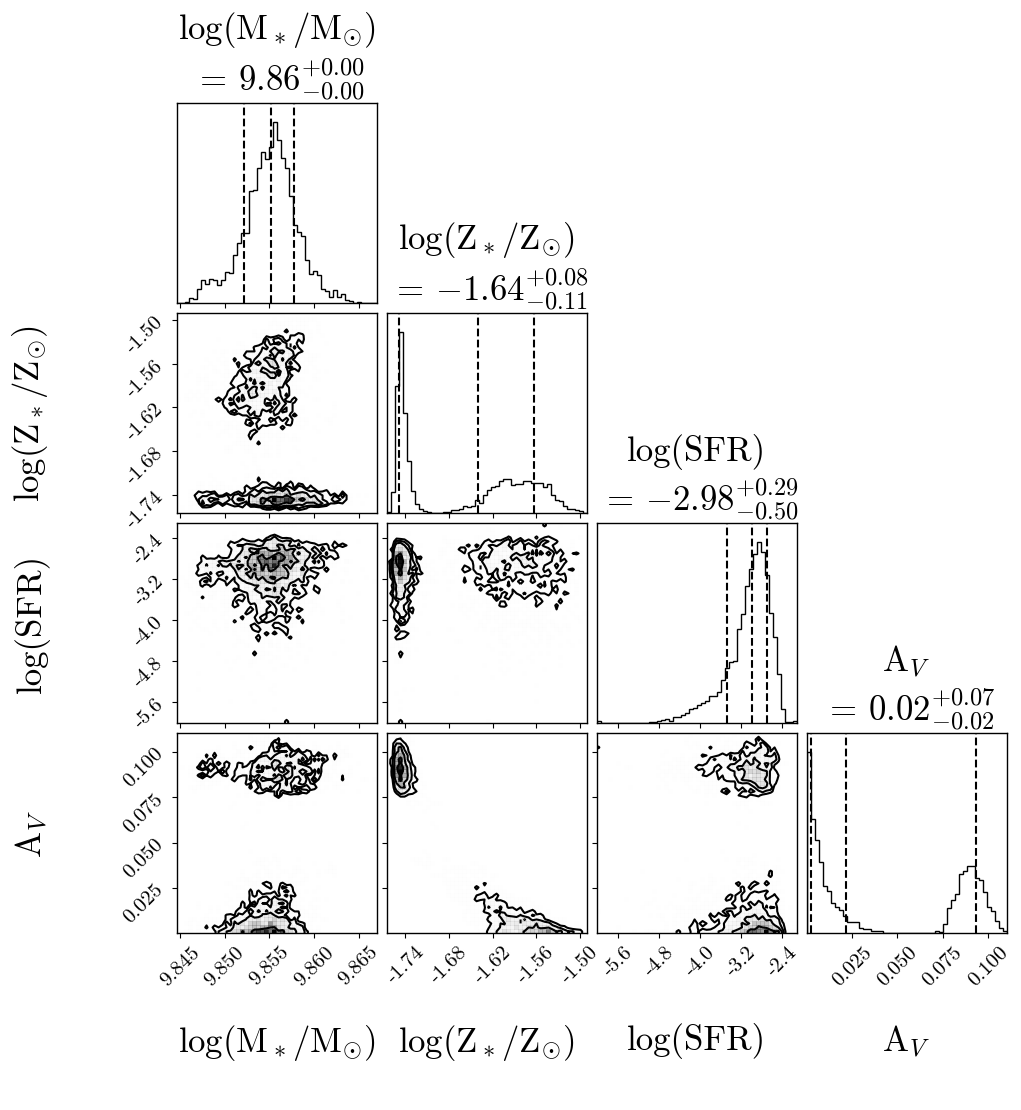

In [ ]:
pf.housestyle_rcparams()
figure = corner.corner(df,labels=list(data.keys()),
                       quantiles=[0.16, 0.5, 0.84],
                       show_titles=True, title_kwargs={"fontsize": 25}, label_kwargs={'fontsize': 25}, labelpad=0.15,
                      bins=50,plot_datapoints=False)